# v1 Two-Tower Game Recommender - Modular Pipeline

Thin orchestration notebook. All logic lives in `v1/src/*.py` modules.  
Original monolithic notebook: `v1/notebooks/v1.ipynb` (canonical reference).

To run: open this notebook from `v1/notebooks/`. Modules are in `v1/src/`.


In [1]:
# -- Environment setup --
import sys
from pathlib import Path

# Notebook is in v1/notebooks/; add v1/ to sys.path so 'from src.module import ...' works.
_v1 = Path.cwd().resolve()
if not (_v1 / "src").exists():
    _v1 = Path.cwd().parent.resolve()
sys.path.insert(0, str(_v1.resolve()))

from src.config import (
    ABLATION, init_environment,
)

import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt

init_environment()
print(f"Running ABLATION = '{ABLATION}'")
print(f"Device: {'cuda' if torch.cuda.is_available() else 'cpu'}")


Running ABLATION = 'no_user_id'
Device: cuda


In [2]:
# -- Stage 1: Data Loading --
from src.loaders import load_raw_games, load_raw_metadata, reservoir_sample_active_users

games = load_raw_games()
games_metadata = load_raw_metadata()
sampled_user_ids, interactions = reservoir_sample_active_users()
print(f"Loaded {len(interactions):,} interactions for {len(sampled_user_ids):,} sampled users.")


Loaded 117,503 interactions for 3,000 sampled users.


In [3]:
# -- Stage 2: Preprocessing --
from src.preprocessing import (
    clean_interactions, apply_engagement_log_transforms, sort_chronologically,
    add_positive_label, clean_metadata, intersect_catalogs,
    filter_to_interacted_catalog, validate_catalog,
)

interactions = clean_interactions(interactions)
interactions = apply_engagement_log_transforms(interactions)
interactions = sort_chronologically(interactions)
interactions = add_positive_label(interactions)
games, games_metadata = clean_metadata(games, games_metadata)
games, games_metadata, interactions, fallback_games = intersect_catalogs(games, games_metadata, interactions)
games, games_metadata = filter_to_interacted_catalog(games, games_metadata, interactions)
stats = validate_catalog(games, games_metadata)
print(f"Catalog: {stats['num_games']:,} games. Metadata coverage: {stats}")


Catalog: 15,068 games. Metadata coverage: {'has_description': 0.9620387576320679, 'has_tags': 0.9624369524820813, 'has_text_metadata': 0.9624369524820813, 'num_games': 15068}


In [4]:
# -- Stage 3: Feature Engineering --
from src.features import (
    engineer_game_features, rescale_positive_ratio,
    enrich_descriptions_with_title, clean_text_for_embeddings,
    encode_tags, encode_descriptions, merge_feature_tables,
    build_weighted_item_matrix,
)

games = engineer_game_features(games)
games = rescale_positive_ratio(games)
games, games_metadata = enrich_descriptions_with_title(games, games_metadata)
games_metadata = clean_text_for_embeddings(games_metadata)
tags_df = encode_tags(games_metadata)
desc_df = encode_descriptions(games_metadata)

availability = games_metadata[["app_id", "has_description", "has_tags", "has_text_metadata"]]
item_features_df = merge_feature_tables(games, tags_df, desc_df, availability)
item_features_df = build_weighted_item_matrix(item_features_df)
print(f"Item feature table: {item_features_df.shape}")


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Batches:   0%|          | 0/471 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Batches:   0%|          | 0/471 [00:00<?, ?it/s]

Item feature table: (15068, 1173)


In [5]:
# -- Full catalog snapshots (pre-warm-filter) --
full_games = games.copy()
full_games_meta = games_metadata.copy()
full_item_features = item_features_df.copy()
print(f"Full item-tower feature table: {full_item_features.shape}")


Full item-tower feature table: (15068, 1173)


In [6]:
# -- Stage 4: Temporal Splitting --
from src.splitting import temporal_split_by_user
from src.config import TRAIN_RATIO, VAL_RATIO

train_int, val_int, test_int = temporal_split_by_user(interactions, TRAIN_RATIO, VAL_RATIO)
print(f"Train: {train_int.shape}, Val: {val_int.shape}, Test: {test_int.shape}")


Temporal user split: 100%|██████████| 3000/3000 [00:01<00:00, 2673.16it/s]


Train: (80961, 7), Val: (17482, 7), Test: (19060, 7)


In [7]:
# -- Engagement strength (train-only fit) --
from src.splitting import (
    fit_engagement_transform, add_engagement_strength,
    retain_train_supported_catalog, filter_splits_to_warm_catalog,
    drop_engagement_log_columns,
)

clip, scaler = fit_engagement_transform(train_int)
train_int = add_engagement_strength(train_int, clip, scaler)
val_int = add_engagement_strength(val_int, clip, scaler)
test_int = add_engagement_strength(test_int, clip, scaler)

full_train = train_int.copy()
full_val = val_int.copy()
full_test = test_int.copy()
print("Engagement strength added.")


Engagement strength added.


In [8]:
# -- Warm catalog stabilization --

train_int = retain_train_supported_catalog(full_train)
val_int, test_int, games, games_metadata, item_features_df = filter_splits_to_warm_catalog(train_int, full_val, full_test, full_games, full_games_meta, full_item_features)

drop_engagement_log_columns(train_int, val_int, test_int)

print(f"Warm: {games.shape[0]:,} items, {train_int['user_id'].nunique():,} users.")
print(f"Train: {train_int.shape}, Val: {val_int.shape}, Test: {test_int.shape}")


Warm: 2,521 items, 2,973 users.
Train: (63289, 5), Val: (12096, 5), Test: (11513, 5)


In [9]:
# -- Export processed data --
from src.config import PROCESSED_DIR

item_features_df.to_csv(PROCESSED_DIR / "item_embeddings_tower_input.csv", index=False)
train_int.to_csv(PROCESSED_DIR / "train_simu_users.csv", index=False)
val_int.to_csv(PROCESSED_DIR / "val_simu_users.csv", index=False)
test_int.to_csv(PROCESSED_DIR / "test_simu_users.csv", index=False)
print(f"Data exported to {PROCESSED_DIR}")


Data exported to /home/ritish/Desktop/projects/game_recommender_system/v1/data/processed


In [10]:
# -- Stage 5: Data Structures & Indexing --
from src.dataset import (
    add_contiguous_indices, positive_history_map, seen_item_map,
    heldout_positive_map, filter_targets_released_by_cutoff,
    build_prefix_examples, create_dataloaders,
)
from src.config import MAX_HISTORY_LENGTH, BATCH_SIZE

# Contiguous indices.
train_int, uid_to_idx, iid_to_idx = add_contiguous_indices(train_int)
for df in [val_int, test_int]:
    df["user_idx"] = df["user_id"].map(uid_to_idx)
    df["item_idx"] = df["app_id"].map(iid_to_idx)

num_items = len(iid_to_idx)
print(f"num_items: {num_items}")

# Release dates for candidate filtering.
idf = item_features_df.copy()
idf["item_idx"] = idf["app_id"].map(iid_to_idx)
idf.dropna(subset=["item_idx"], inplace=True)
idf["item_idx"] = idf["item_idx"].astype("int64")
idf.sort_values("item_idx", inplace=True)
warm_item_release_dates = idf["date_release"].values

# History maps.
train_pos_hist = positive_history_map(train_int)
train_seen = seen_item_map(train_int)
val_hist = positive_history_map(train_int)
test_hist = positive_history_map(train_int, val_int)
train_val_seen = seen_item_map(train_int, val_int)

# Heldout positives.
val_targets = heldout_positive_map(val_int, train_seen)
test_targets = heldout_positive_map(test_int, train_val_seen)

# Candidate cutoffs.
max_train_dates = train_int.groupby("user_idx")["date"].max()
tc = pd.concat([train_int, val_int]).groupby("user_idx")["date"].max()
val_cutoffs = max_train_dates.to_dict()
test_cutoffs = tc.to_dict()

# Filter targets by release date.
val_targets = filter_targets_released_by_cutoff(val_targets, val_cutoffs, warm_item_release_dates)
test_targets = filter_targets_released_by_cutoff(test_targets, test_cutoffs, warm_item_release_dates)

# Prefix examples.
train_examples = build_prefix_examples(train_pos_hist, MAX_HISTORY_LENGTH)
print(f"Training examples: {len(train_examples):,}")


num_items: 2521
Training examples: 51,239


In [11]:
# -- DataLoaders + train_pos_mask --
import torch

train_loader, full_train_loader, num_users, padding_item_idx = create_dataloaders(
    train_examples, num_items, BATCH_SIZE, MAX_HISTORY_LENGTH
)

train_pos_mask = torch.zeros(num_users, num_items, dtype=torch.bool)
for _, row in train_int[train_int["is_positive"] == 1].iterrows():
    train_pos_mask[int(row["user_idx"]), int(row["item_idx"])] = True

print(f"DataLoader ready. users={num_users}, items={num_items}, padding={padding_item_idx}")


DataLoader ready. users=2973, items=2521, padding=2521


In [12]:
# -- Stage 6: Model --
from src.model import TwoTowerModel

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Align item features to contiguous indices.
idf_sorted = idf.copy()
assert idf_sorted["item_idx"].tolist() == list(range(num_items))

feat_cols = [c for c in idf_sorted.columns if c not in ["app_id", "item_idx", "date_release"]]
item_features = torch.tensor(idf_sorted[feat_cols].to_numpy(dtype=np.float32), dtype=torch.float32)

model = TwoTowerModel(
    num_users=num_users, num_items=num_items,
    item_feature_dim=item_features.shape[1],
    padding_idx=padding_item_idx, ablation=ABLATION,
).to(device)
print(f"Model ready. Params: {sum(p.numel() for p in model.parameters()):,}")


Model ready. Params: 1,237,594


In [13]:
# -- Stage 7: Baselines --
from src.baselines import compute_item_popularity_log

item_popularity_log = compute_item_popularity_log(train_int, num_items)
popularity_ranking = item_popularity_log.argsort(descending=True).tolist()
print("Popularity scores computed.")


Popularity scores computed.


In [14]:
# -- Stage 8: Training --
from src.training import train_model
from src.config import HYBRID_ALPHA

results = train_model(
    model=model, train_loader=train_loader,
    item_features=item_features, train_pos_mask=train_pos_mask,
    train_examples=train_examples, num_items=num_items,
    val_positive_targets=val_targets, val_user_histories=val_hist,
    train_seen=train_seen, val_candidate_cutoffs=val_cutoffs,
    item_popularity_log=item_popularity_log,
    warm_item_release_dates=warm_item_release_dates,
    device=device, padding_idx=padding_item_idx,
    hybrid_alpha=HYBRID_ALPHA, ablation=ABLATION,
)
print(f"Best epoch: {results['best_epoch']}, Val R@10: {results['best_val_recall']:.4f}")


                       EXPERIMENT TRACKING                       
  Model: Two-Tower (embed_dim=128, hidden=256, heads=4)
  Ablation: no_user_id
  Optimizer: AdamW (lr=3e-4, wd=1e-4)
  Scheduler: ReduceLROnPlateau (mode=max, patience=3)
  LogQ: corrected (1-(1-p)^B), B=512
  Early stopping: patience=6 epochs
  Train examples: 51,239 | Items: 2,521
Epoch 01 | loss=6.2809 | val R@10=0.0492 | lr=3.00e-04 | 5s*
Epoch 02 | loss=5.8169 | val R@10=0.0573 | lr=3.00e-04 | 10s*
Epoch 03 | loss=5.5673 | val R@10=0.0615 | lr=3.00e-04 | 15s*
Epoch 04 | loss=5.3880 | val R@10=0.0691 | lr=3.00e-04 | 20s*
Epoch 05 | loss=5.2433 | val R@10=0.0707 | lr=3.00e-04 | 25s*
Epoch 06 | loss=5.1163 | val R@10=0.0742 | lr=3.00e-04 | 29s*
Epoch 07 | loss=5.0070 | val R@10=0.0775 | lr=3.00e-04 | 34s*
Epoch 08 | loss=4.9038 | val R@10=0.0745 | lr=3.00e-04 | 39s 
Epoch 09 | loss=4.8012 | val R@10=0.0787 | lr=3.00e-04 | 43s*
Epoch 10 | loss=4.7173 | val R@10=0.0763 | lr=3.00e-04 | 48s 
Epoch 11 | loss=4.6237 | val R@

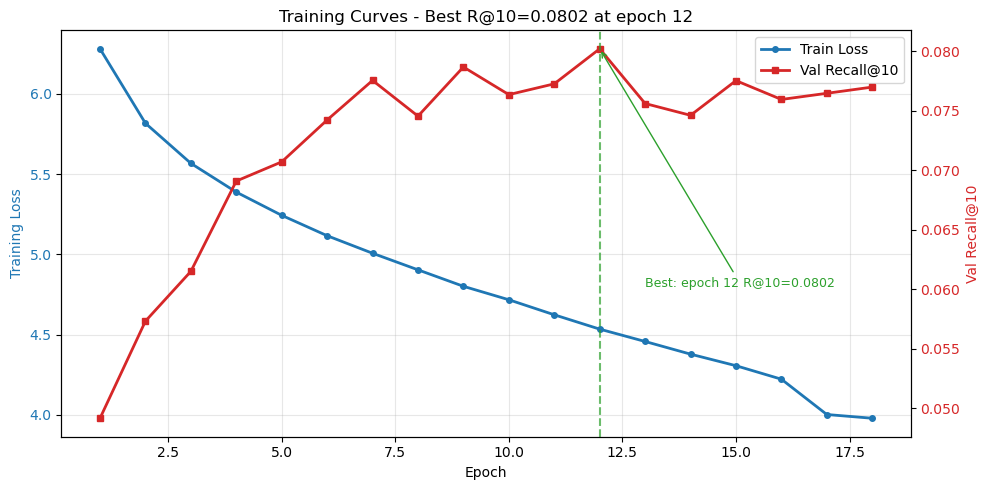

In [15]:
# -- Training curves --
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(10, 5))
epochs = range(1, len(results["train_losses"]) + 1)

ax1.set_xlabel("Epoch")
ax1.set_ylabel("Training Loss", color="#1f77b4")
ax1.plot(epochs, results["train_losses"], color="#1f77b4", marker="o", lw=2, ms=4, label="Train Loss")
ax1.tick_params(axis="y", labelcolor="#1f77b4")

ax2 = ax1.twinx()
ax2.set_ylabel("Val Recall@10", color="#d62728")
ax2.plot(epochs, results["val_recalls"], color="#d62728", marker="s", lw=2, ms=4, label="Val Recall@10")
ax2.tick_params(axis="y", labelcolor="#d62728")

bi = results["val_recalls"].index(max(results["val_recalls"]))
ax2.axvline(x=epochs[bi], color="#2ca02c", linestyle="--", alpha=0.7, lw=1.5)
ax2.annotate(f"Best: epoch {epochs[bi]} R@10={results['val_recalls'][bi]:.4f}",  xy=(epochs[bi], results["val_recalls"][bi]),
             xytext=(epochs[bi]+1, results["val_recalls"][bi]-0.02),
             arrowprops=dict(arrowstyle="->", color="#2ca02c"), fontsize=9, color="#2ca02c")
ax1.set_title(f"Training Curves - Best R@10={results['val_recalls'][bi]:.4f} at epoch {epochs[bi]}")
ax1.grid(True, alpha=0.3)
l1, la1 = ax1.get_legend_handles_labels()
l2, la2 = ax2.get_legend_handles_labels()
ax1.legend(l1 + l2, la1 + la2, loc="upper right")
fig.tight_layout()
plt.show()


In [16]:
# -- Stage 9: Full Evaluation --
from src.evaluation import evaluate_filtered
from src.config import EVAL_K

vm = evaluate_filtered(model, val_targets, val_hist, train_seen, val_cutoffs,
                       item_features, warm_item_release_dates, device,
                       k=EVAL_K, hybrid_alpha=HYBRID_ALPHA,
                       item_popularity_log=item_popularity_log, padding_idx=padding_item_idx)
tm = evaluate_filtered(model, test_targets, test_hist, train_val_seen, test_cutoffs,
                       item_features, warm_item_release_dates, device,
                       k=EVAL_K, hybrid_alpha=HYBRID_ALPHA,
                       item_popularity_log=item_popularity_log, padding_idx=padding_item_idx)
print("Model - Val:", vm)
print("Model - Test:", tm)


Model - Val: {'HitRate@10': 0.20357420357420358, 'Precision@10': 0.023193473193473195, 'Recall@10': 0.08019246104739043, 'users_evaluated': 2574}
Model - Test: {'HitRate@10': 0.1638418079096045, 'Precision@10': 0.01811945117029863, 'Recall@10': 0.06433676799978347, 'users_evaluated': 2478}


In [17]:
# -- Baselines --
from src.baselines import evaluate_popularity_baseline, evaluate_random_expected_baseline, evaluate_content_centroid_baseline

vp = evaluate_popularity_baseline(val_targets, val_hist, train_seen, val_cutoffs, popularity_ranking, warm_item_release_dates, k=EVAL_K)
tp = evaluate_popularity_baseline(test_targets, test_hist, train_val_seen, test_cutoffs, popularity_ranking, warm_item_release_dates, k=EVAL_K)
vr = evaluate_random_expected_baseline(val_targets, val_hist, train_seen, val_cutoffs, warm_item_release_dates, k=EVAL_K)
tr = evaluate_random_expected_baseline(test_targets, test_hist, train_val_seen, test_cutoffs, warm_item_release_dates, k=EVAL_K)
vc = evaluate_content_centroid_baseline(val_targets, val_hist, train_seen, val_cutoffs, item_features, warm_item_release_dates, k=EVAL_K)
tc2 = evaluate_content_centroid_baseline(test_targets, test_hist, train_val_seen, test_cutoffs, item_features, warm_item_release_dates, k=EVAL_K)


In [18]:
# -- Results comparison table --
print("=" * 90)
print(f"{'COMPARISON TABLE':^90}")
print("=" * 90)
print(f"{'Method':<18} {'Val HR@10':>11} {'Val R@10':>10} {'Test HR@10':>12} {'Test R@10':>11}")
print("-" * 90)
for name, vm_, tm_ in [("Two-Tower", vm, tm), ("Popularity", vp, tp), ("Random", vr, tr), ("Content", vc, tc2)]:
    print(f"{name:<18} {vm_['HitRate@10']:>11.4f} {vm_['Recall@10']:>10.4f} {tm_['HitRate@10']:>12.4f} {tm_['Recall@10']:>11.4f}")
print("=" * 90)


                                     COMPARISON TABLE                                     
Method               Val HR@10   Val R@10   Test HR@10   Test R@10
------------------------------------------------------------------------------------------
Two-Tower               0.2036     0.0802       0.1638      0.0643
Popularity              0.1088     0.0392       0.0900      0.0336
Random                  0.0148     0.0050       0.0132      0.0046
Content                 0.0820     0.0318       0.0738      0.0279


In [20]:
# -- HYBRID_ALPHA sweep --
best_a, best_r = None, -1.0
rows = []
for a in [0.0, 0.1, 0.2, 0.3, 0.4, 0.5]:
    vm_a = evaluate_filtered(model, val_targets, val_hist, train_seen, val_cutoffs,
                             item_features, warm_item_release_dates, device,
                             k=EVAL_K, hybrid_alpha=a, item_popularity_log=item_popularity_log, padding_idx=padding_item_idx)
    tm_a = evaluate_filtered(model, test_targets, test_hist, train_val_seen, test_cutoffs,
                             item_features, warm_item_release_dates, device,
                             k=EVAL_K, hybrid_alpha=a, item_popularity_log=item_popularity_log, padding_idx=padding_item_idx)
    rows.append((a, vm_a, tm_a))
    if tm_a["Recall@10"] > best_r:
        best_r, best_a = tm_a["Recall@10"], a

print(f"{'alpha':>6} {'Val R@10':>10} {'Test R@10':>11}")
print("-" * 32)
for a, vm_a, tm_a in rows:
    m = " <--" if a == best_a else ""
    print(f"{a:>6.1f} {vm_a['Recall@10']:>10.4f} {tm_a['Recall@10']:>11.4f}{m}")
print(f"Best alpha = {best_a} (test R@10 = {best_r:.4f})")


 alpha   Val R@10   Test R@10
--------------------------------
   0.0     0.0860      0.0713
   0.1     0.0914      0.0788 <--
   0.2     0.0802      0.0643
   0.3     0.0664      0.0567
   0.4     0.0589      0.0507
   0.5     0.0550      0.0467
Best alpha = 0.1 (test R@10 = 0.0788)


In [21]:
# -- Ablation summary --
import json
from src.config import ABLATION_RESULTS_PATH

if ABLATION_RESULTS_PATH.exists():
    all_res = json.loads(ABLATION_RESULTS_PATH.read_text())
    print(f"{'Ablation':<16} {'Best Ep':>8} {'Best Val R@10':>14} {'Time(min)':>10}")
    print("-" * 52)
    for r in sorted(all_res, key=lambda x: x.get("best_val_recall", 0), reverse=True):
        print(f"{r.get('ablation','?'):<16} {str(r.get('best_epoch','?')):>8} {r.get('best_val_recall',0):>14.4f} {r.get('total_train_time_s',0)/60:>9.1f}")
else:
    print("No ablation_results.json yet.")


Ablation          Best Ep  Best Val R@10  Time(min)
----------------------------------------------------
no_user_id             12         0.0802       1.4


In [22]:
# -- Cold-start --
from src.cold_start import recommend_cold_start_v1

recs = recommend_cold_start_v1(fallback_games, full_train, n=10, item_id_to_idx=iid_to_idx)
recs


,app_id,warm_item_idx,cold_start_score
0,620,306.0,0.980322
1,431960,19.0,0.980239
2,400,279.0,0.979885
3,1145360,411.0,0.979461
4,413150,143.0,0.979136
5,294100,196.0,0.979136
6,253230,611.0,0.978290
7,546560,841.0,0.977388
8,550,259.0,0.977097
9,460950,374.0,0.976957
